In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)


In [5]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

In [6]:
class_names[9]

'Ankle Boot'

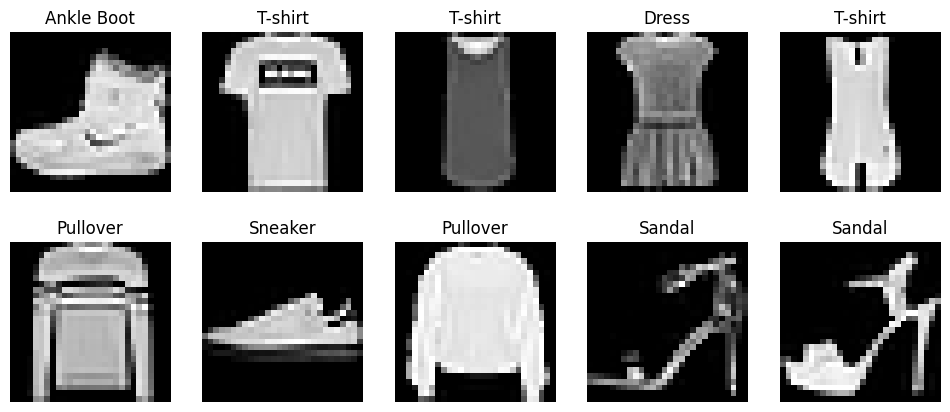

In [7]:
plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(train_images[i], cmap="gray")

    plt.title(class_names[train_labels[i]])

    plt.axis("off")

plt.show()

In [8]:
train_images = train_images / 255.0

test_images = test_images / 255.0

In [9]:
train_images = train_images[..., np.newaxis]

test_images = test_images[..., np.newaxis]

In [10]:
print(train_images.shape)

(60000, 28, 28, 1)


In [11]:
from tensorflow.keras import models, layers

model = models.Sequential()

In [12]:
model.add(
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-14 08:43:55.753464: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
model.add(
    layers.MaxPooling2D(pool_size=(2,2))
)

In [14]:
model.add(
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

In [15]:
model.add(
    layers.MaxPooling2D(pool_size=(2,2))
)

In [16]:
model.add(
    layers.Flatten()
)

In [17]:
model.add(
    layers.Dense(
        64,
        activation='relu'
    )
)

In [18]:
model.add(
    layers.Dense(
        10,
        activation='softmax'
    )
)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.8263 - loss: 0.4821 - val_accuracy: 0.8611 - val_loss: 0.3961
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.8845 - loss: 0.3189 - val_accuracy: 0.8945 - val_loss: 0.3015
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.8987 - loss: 0.2768 - val_accuracy: 0.8992 - val_loss: 0.2777
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9091 - loss: 0.2457 - val_accuracy: 0.8977 - val_loss: 0.2834
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9193 - loss: 0.2194 - val_accuracy: 0.8976 - val_loss: 0.2933
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9261 - loss: 0.1979 - val_accuracy: 0.9052 - val_loss: 0.2612
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9327 - loss: 0.1777 - val_accuracy: 0.9089 - val_loss: 0.2673
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9406 -

In [22]:
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9116 - loss: 0.2835


In [23]:
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

Test Accuracy: 0.9115999937057495
Test Loss: 0.283535361289978


In [24]:
train_loss, train_accuracy = model.evaluate(
    train_images,
    train_labels,
    verbose=0
)

In [25]:
print("Training Accuracy:", train_accuracy)
print("Training Loss:", train_loss)

Training Accuracy: 0.9524000287055969
Training Loss: 0.13783514499664307


In [26]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [28]:
predicted_label = np.argmax(predictions[0])

In [29]:
print("Predicted:", class_names[predicted_label])
print("Actual:", class_names[test_labels[0]])

Predicted: Ankle Boot
Actual: Ankle Boot


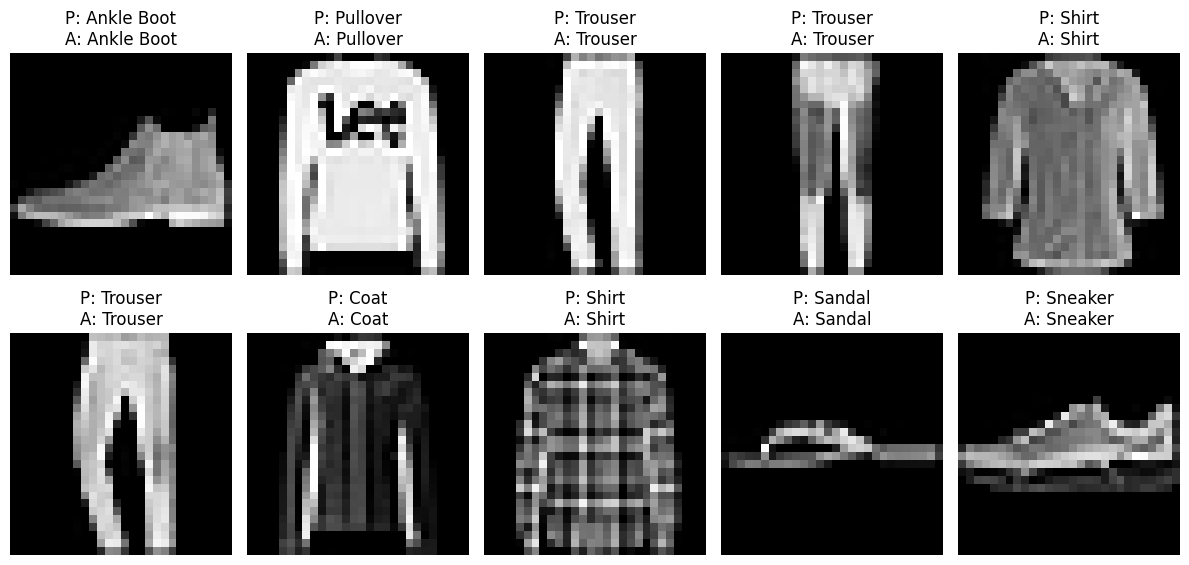

In [30]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(test_images[i].squeeze(), cmap='gray')

    pred = np.argmax(predictions[i])

    plt.title(f"P: {class_names[pred]}\nA: {class_names[test_labels[i]]}")

    plt.axis('off')

plt.tight_layout()
plt.show()

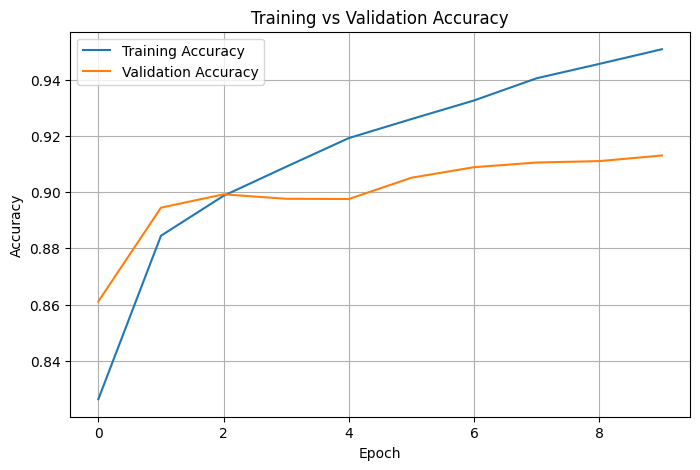

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

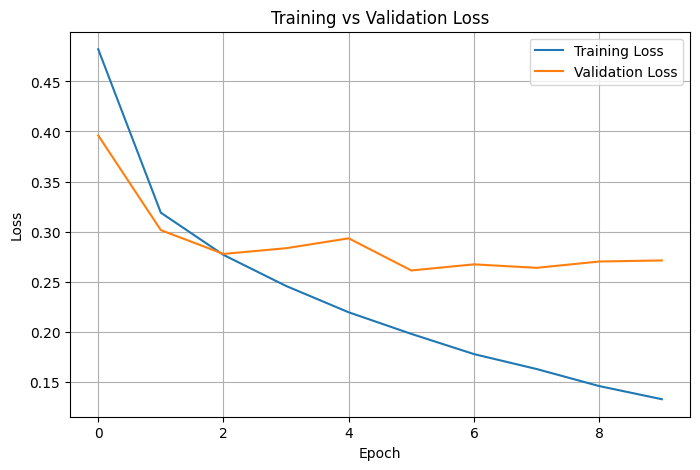

In [33]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [36]:
# Predict all test images

predictions = model.predict(test_images)

# Convert probabilities into class numbers

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

<Figure size 1000x800 with 0 Axes>

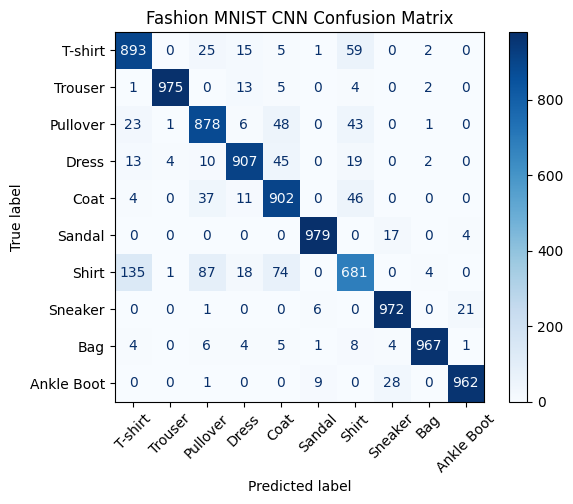

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Fashion MNIST CNN Confusion Matrix")
plt.show()